In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sentiment=pd.read_csv("sentiment.csv")
historical = pd.read_csv("historical.csv")
print(sentiment.shape)
print(historical.shape)

(2644, 4)
(211224, 16)


In [2]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [3]:
historical.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [4]:
sentiment.duplicated().sum()

np.int64(0)

In [5]:
historical.duplicated().sum()

np.int64(0)

In [6]:
historical['Timestamp IST'] = pd.to_datetime(historical['Timestamp IST'],format = '%d-%m-%Y %H:%M')
print(historical['Timestamp IST'])

0        2024-12-02 22:50:00
1        2024-12-02 22:50:00
2        2024-12-02 22:50:00
3        2024-12-02 22:50:00
4        2024-12-02 22:50:00
                 ...        
211219   2025-04-25 15:35:00
211220   2025-04-25 15:35:00
211221   2025-04-25 15:35:00
211222   2025-04-25 15:35:00
211223   2025-04-25 15:35:00
Name: Timestamp IST, Length: 211224, dtype: datetime64[ns]


In [7]:
historical['date'] = historical['Timestamp IST'].dt.date
print(historical['date'])

0         2024-12-02
1         2024-12-02
2         2024-12-02
3         2024-12-02
4         2024-12-02
             ...    
211219    2025-04-25
211220    2025-04-25
211221    2025-04-25
211222    2025-04-25
211223    2025-04-25
Name: date, Length: 211224, dtype: object


In [8]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
print(sentiment['date'])

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, Length: 2644, dtype: object


In [9]:
merged= pd.merge(historical,sentiment, on ='date', how='left')

In [10]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [11]:
daily_pnl= merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
print(daily_pnl)

                                         Account        date    Closed PnL
0     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11      0.000000
1     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17      0.000000
2     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18      0.000000
3     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22 -21227.000000
4     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26   1603.100000
...                                          ...         ...           ...
2336  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-27   1709.194807
2337  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-28   4008.588908
2338  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-29   8561.771838
2339  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-30   2520.773814
2340  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-05-01   1364.022527

[2341 rows x 3 columns]


In [12]:
merged['win']=merged['Closed PnL']>0
print(merged['win'])

0         False
1         False
2         False
3         False
4         False
          ...  
211219    False
211220    False
211221    False
211222    False
211223    False
Name: win, Length: 211224, dtype: bool


In [13]:
win_rate=merged.groupby('Account')['win'].mean()
print(win_rate)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    0.345912
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    0.306294
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0x

In [14]:
merged['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [15]:
long_short_ratio= merged.groupby(['date','Side']).size().unstack()
print(long_short_ratio)

Side           BUY    SELL
date                      
2023-05-01     3.0     NaN
2023-12-05     7.0     2.0
2023-12-14     5.0     6.0
2023-12-15     2.0     NaN
2023-12-16     3.0     NaN
...            ...     ...
2025-04-27   209.0   128.0
2025-04-28   652.0   727.0
2025-04-29  1105.0  1138.0
2025-04-30   838.0   275.0
2025-05-01   686.0   544.0

[480 rows x 2 columns]


In [16]:
trades_per_day=merged.groupby('date')['Trade ID'].count().reset_index()
trades_per_day.columns= ['date','trade_count']
print(trades_per_day)

           date  trade_count
0    2023-05-01            3
1    2023-12-05            9
2    2023-12-14           11
3    2023-12-15            2
4    2023-12-16            3
..          ...          ...
475  2025-04-27          337
476  2025-04-28         1379
477  2025-04-29         2243
478  2025-04-30         1113
479  2025-05-01         1230

[480 rows x 2 columns]


In [17]:
Average_trade_size = merged.groupby('date')['Size USD'].mean().reset_index()
print(Average_trade_size)

           date      Size USD
0    2023-05-01    159.000000
1    2023-12-05   5556.203333
2    2023-12-14  10291.213636
3    2023-12-15   5304.975000
4    2023-12-16   5116.256667
..          ...           ...
475  2025-04-27   1446.699377
476  2025-04-28  18944.830667
477  2025-04-29  15198.177289
478  2025-04-30  11405.102291
479  2025-05-01   8715.642699

[480 rows x 2 columns]


In [18]:
leverage_dist= merged['Start Position'].value_counts().sort_index()
leverage_dist.describe()

count    196923.000000
mean          1.072622
std           9.223117
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        4085.000000
Name: count, dtype: float64

In [19]:
sentiment_pnl= merged.groupby('classification')['Closed PnL'].mean()
print(sentiment_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


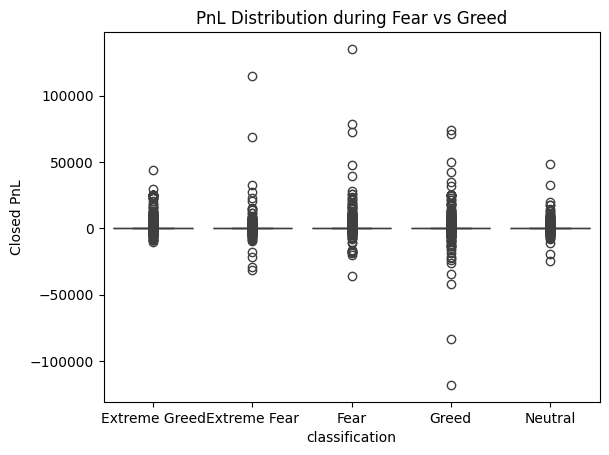

In [20]:
sns.boxplot(x='classification', y='Closed PnL',data=merged)
plt.title("PnL Distribution during Fear vs Greed")
plt.show()

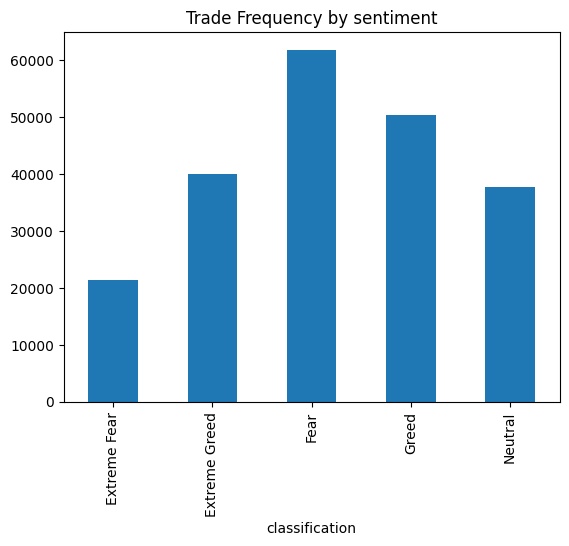

In [21]:
sentiment_trades=merged.groupby('classification')['Trade ID'].count()
sentiment_trades.plot(kind="bar")
plt.title("Trade Frequency by sentiment")
plt.show()

In [22]:
merged['leverage_group']= pd.qcut(merged['Size USD'],2, labels=['low','high'])
print(merged['leverage_group'])

0         high
1          low
2         high
3         high
4          low
          ... 
211219     low
211220    high
211221     low
211222    high
211223    high
Name: leverage_group, Length: 211224, dtype: category
Categories (2, object): ['low' < 'high']


In [23]:
trade_counts=merged.groupby('Account')['Trade ID'].count()
frequent_traders =trade_counts[trade_counts>trade_counts.median()]
print(frequent_traders)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0x271b280974205ca63b716753467d5a371de622ab     3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
Name: Trade ID, dtype: int64


In [24]:
trader_pnl= merged.groupby('Account')['Closed PnL'].mean()
consistent_winners= trader_pnl[trader_pnl>0]
print(consistent_winners)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    419.127768
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd      6.577654
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      9.951530
0x2c229d22b100a7beb69122eed721cee9b24011dd     52.071011
0x39cef799f8b69da1995852eea189df24eb5cae3c      4.028119
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    161.133275
0x420ab45e0bd8863569a5efbb9c05d91f40624641    520.902331
0x430f09841d65beb3f27765503d0f850b8bce7713    336.735548
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     12.130968
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    155.589314
0x4f93fead39b70a1824f981a54d4e55b278e9f760     40.740489
0x513b8629fe877bb581bf244e326a047b249c4ff1     68.684419
0x6d6a4b953f202f8df5bed40692e7fd865318264a    111.519197
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    270.034947
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    281.826227
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     38.319560
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f      9.557693
0x8381e6d82f1affd39a336

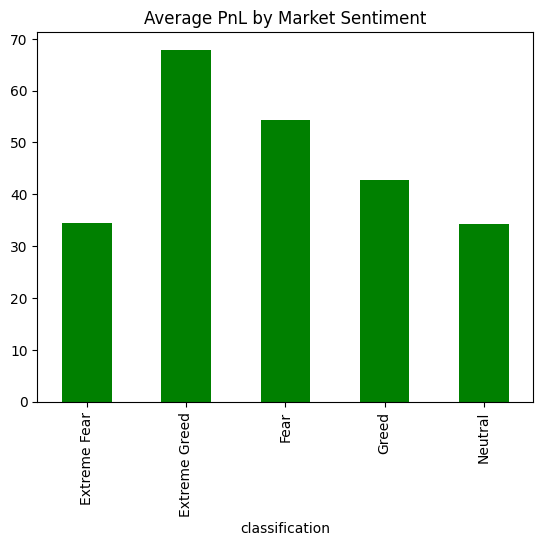

In [25]:
## Sentiment vs Average PnL##
merged.groupby('classification')['Closed PnL'].mean().plot(kind='bar', color='green')
plt.title("Average PnL by Market Sentiment")
plt.show()

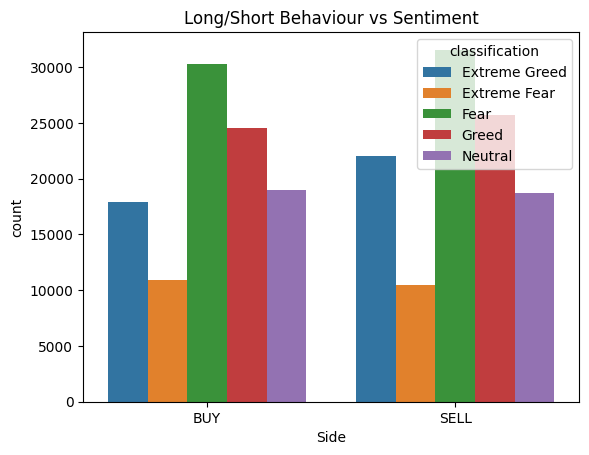

In [26]:
## Long vs Short##

sns.countplot(x='Side',hue='classification', data =merged)
plt.title("Long/Short Behaviour vs Sentiment")
plt.show()

Methodology:
    - Two datasets were used for this analysis: a) Bitcoin Market Sentiment dataset b) Hyperliquid Historical Trader dataset.
    - The following steps were performed:
          a) Loaded both datasets using Pandas
          b) Checked for any missing or duplicate values
          c) Converted timestamps to datetime format
          d)Merged both datasets and created some key metrices

Insights :
  1)During Fear periods, traders show higher trade frequency but lower average PnL.
  2)During Greed periods, traders take larger position sizes, increasing volatility.
  3)High leverage traders show larger profits but higher losses.
    
Strategy1: Sentiment based leverage control-
            - During Fear periods reduce leverage and position size to manage downside risk.
            - During Greed periods, moderate leverage and increased long exposure may improve returns.

Strategy2: Sentiment adaptive trade direction-
            -Favor short trades during Fear markets.
            -Favor long trades during Greed markets.